<a href="https://colab.research.google.com/github/meryymarta/DataMining/blob/main/Cleaning_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


/tmp/ipykernel_692/1098112056.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace = True)
/tmp/ipykernel_692/1098112056.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Kolom data train dengan nilai NULL:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
----------
Kolom data test dengan nilai NULL:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64
--------------- 

Korelasi Survival dengan: Sex
      Sex  Survived
0  female  0.742038
1    male  0.188908
---------- 

Korelasi Survival dengan: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Korelasi Survival dengan: Embarked
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.339009
---------- 

Korelasi Survival dengan: Title
    Title  Survived
0  Master  0.575000
1    Misc  0.444444
2    Miss  0.697802
3      Mr  0.156673
4     Mrs  0.792000
---------- 

Korelasi Surv

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,FareBin,AgeBin
181,0,2,"Pernot, Mr. Rene",male,28.0,0,0,15.0500,C,1,1,Mr,"(14.454, 31.0]","(16.0, 32.0]"
285,0,3,"Stankovic, Mr. Ivan",male,33.0,0,0,8.6625,C,1,1,Mr,"(7.91, 14.454]","(32.0, 48.0]"
581,1,1,"Thayer, Mrs. John Borland (Marian Longstreth M...",female,39.0,1,1,110.8833,C,3,0,Mrs,"(31.0, 512.329]","(32.0, 48.0]"
780,1,3,"Ayoub, Miss. Banoura",female,13.0,0,0,7.2292,C,1,1,Miss,"(-0.001, 7.91]","(-0.08, 16.0]"
675,0,3,"Edvardsson, Mr. Gustaf Hjalmar",male,18.0,0,0,7.7750,S,1,1,Mr,"(-0.001, 7.91]","(16.0, 32.0]"
588,0,3,"Gilinski, Mr. Eliezer",male,22.0,0,0,8.0500,S,1,1,Mr,"(7.91, 14.454]","(16.0, 32.0]"
470,0,3,"Keefe, Mr. Arthur",male,28.0,0,0,7.2500,S,1,1,Mr,"(-0.001, 7.91]","(16.0, 32.0]"
401,0,3,"Adams, Mr. John",male,26.0,0,0,8.0500,S,1,1,Mr,"(7.91, 14.454]","(16.0, 32.0]"
448,1,3,"Baclini, Miss. Marie Catherine",female,5.0,2,1,19.2583,C,4,0,Miss,"(14.454, 31.0]","(-0.08, 16.0]"
277,0,2,"Parkes, Mr. Francis ""Frank""",male,28.0,0,0,0.0000,S,1,1,Mr,"(-0.001, 7.91]","(16.0, 32.0]"



Menampilkan Grafik Deskriptif...


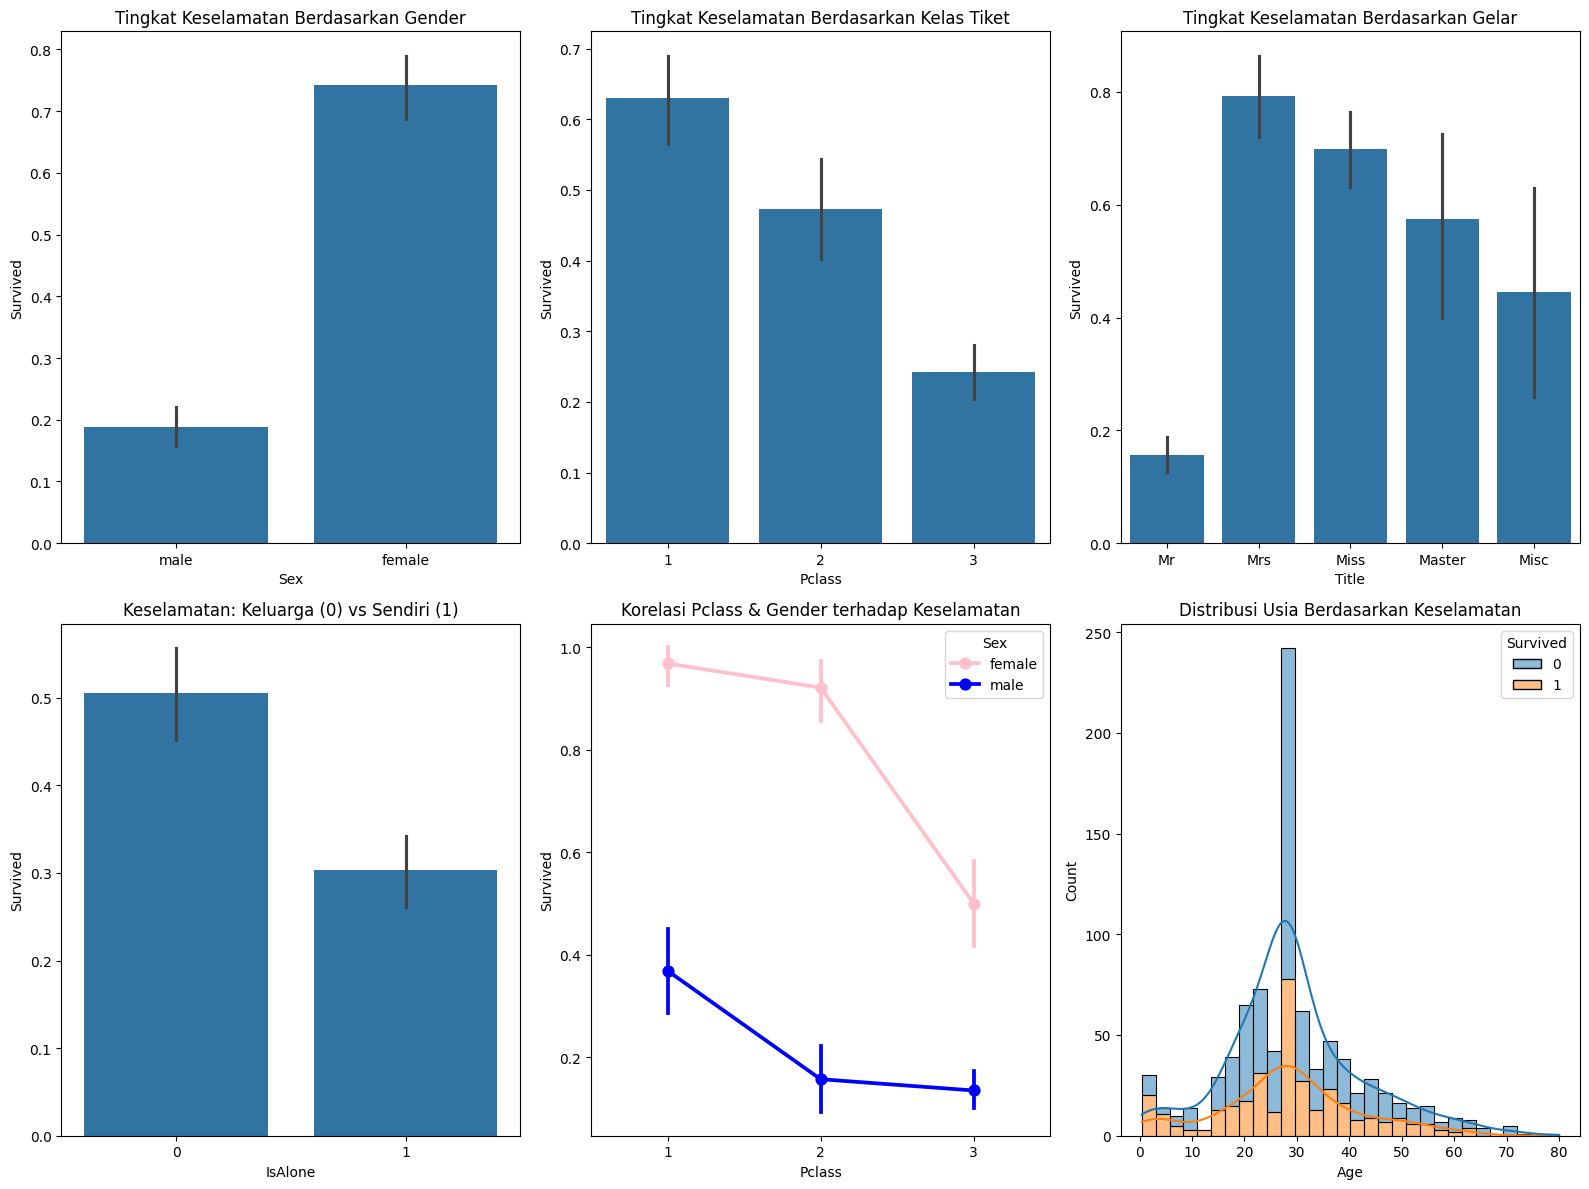

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

# Membaca file
data_raw = pd.read_csv('/content/drive/MyDrive/kuliah/train.csv')
data_val = pd.read_csv('/content/drive/MyDrive/kuliah/test.csv')

# membuat salinan untuk data train agar data aslinya (data_raw) tetap utuh
data1 = data_raw.copy(deep = True)

# Memasukkan data train (data1) dan data test (data_val) ke dalam list
data_cleaner = [data1, data_val]

# proses pengisian data kosong (berlaku untuk train dan test)
for dataset in data_cleaner:
    # Isikan age yang kosong dengan median
    dataset['Age'].fillna(dataset['Age'].median(), inplace = True)

    # Isikan embarked dengan modus
    dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace = True)

    # Isikan fare dengan median
    dataset['Fare'].fillna(dataset['Fare'].median(), inplace = True)

# proses hapus kolom hanya untuk data train (data1)
drop_column = ['PassengerId', 'Cabin', 'Ticket']
data1.drop(drop_column, axis=1, inplace = True)

# cetak Hasil Akhir
print('Kolom data train dengan nilai NULL:')
print(data1.isnull().sum())
print("-" * 10)

print('Kolom data test dengan nilai NULL:')
print(data_val.isnull().sum())
print("-" * 15, "\n")

# Feature Engineering
for dataset in data_cleaner:
    #variable descrete
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

    dataset['IsAlone'] = 1 #diisikan 1 jika sendiri
    dataset.loc[dataset['FamilySize'] > 1, 'IsAlone'] = 0 #isikan 0 jika ada relasi yang bersama

    #pisahkan title dari nama: http://www.pythonforbeginners.com/dictionary/python-split
    dataset['Title'] = dataset['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

    #buat bin Fare menggunakan 1cut atau bin Frekuensi
    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)

    #buat bin Age menggunakan cut or nilai bin
    dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)

    #bersihkan title yang jarang ada
    stat_min = 10
    title_names = (dataset['Title'].value_counts() < stat_min)

    dataset['Title'] = dataset['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)

# --- DEFINISI TARGET DAN FITUR (Agar tidak error saat mengecek korelasi) ---
Target = ['Survived']
data1_x = ['Sex', 'Pclass', 'Embarked', 'Title', 'SibSp', 'Parch', 'Age', 'Fare', 'FamilySize', 'IsAlone']

#Discrete Variable Correlation dengan Survival menggunakan
#group by / pivot table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html
for x in data1_x:
    if data1[x].dtype != 'float64' :
        print('Korelasi Survival dengan:', x)
        print(data1[[x, Target[0]]].groupby(x, as_index=False).mean())
        print('-'*10, '\n')

#menggunakan crosstabs: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.crosstab.html
print("Crosstab Title vs Survived:")
print(pd.crosstab(data1['Title'], data1[Target[0]]))
print("-" * 15, "\n")

#tampilkan data lagi di akhir agar rapi
data1.info()
print("-" * 15)
data_val.info()
print("-" * 15)
display(data1.sample(10))

#Menampilkan Grafik
print("\nMenampilkan Grafik Deskriptif...")

# Mengatur tata letak dan ukuran seluruh figur grafik
plt.figure(figsize=[16,12])

# 1. Barplot Keselamatan berdasarkan Jenis Kelamin (Sex)
plt.subplot(231)
sns.barplot(x='Sex', y='Survived', data=data1)
plt.title('Tingkat Keselamatan Berdasarkan Gender')

# 2. Barplot Keselamatan berdasarkan Kelas Penumpang (Pclass)
plt.subplot(232)
sns.barplot(x='Pclass', y='Survived', data=data1)
plt.title('Tingkat Keselamatan Berdasarkan Kelas Tiket')

# 3. Barplot Keselamatan berdasarkan Gelar (Title)
plt.subplot(233)
sns.barplot(x='Title', y='Survived', data=data1)
plt.title('Tingkat Keselamatan Berdasarkan Gelar')

# 4. Barplot Keselamatan berdasarkan Status Sendiri/Keluarga (IsAlone)
plt.subplot(234)
sns.barplot(x='IsAlone', y='Survived', data=data1)
plt.title('Keselamatan: Keluarga (0) vs Sendiri (1)')

# 5. Pointplot untuk melihat korelasi Kelas, Gender, dan Keselamatan sekaligus
plt.subplot(235)
sns.pointplot(x='Pclass', y='Survived', hue='Sex', data=data1, palette={'male': 'blue', 'female': 'pink'})
plt.title('Korelasi Pclass & Gender terhadap Keselamatan')

# 6. Histogram Distribusi Usia (Age) berdasarkan Keselamatan
plt.subplot(236)
sns.histplot(data=data1, x='Age', hue='Survived', kde=True, multiple="stack")
plt.title('Distribusi Usia Berdasarkan Keselamatan')

# Menyesuaikan jarak antar grafik agar tidak bertumpuk
plt.tight_layout()
# Menampilkan grafik
plt.show()